# 06 — Does the critic work on a database it has never seen?

Everything reported so far — PR-AUC 0.9845, 34% of steps saved, 81 of 83
answers kept — was measured on **questions the critic saw during training**.
Different runs of the same 120 questions, split by `run_id`.

That leaves the product claim untested. The agent is meant to work on a user's
own database. If the critic has partly learned *which questions are hard*
rather than *which steps are bad*, none of those numbers transfer.

Notebook 05 tried to check this and couldn't: all 1,030 test steps were on
questions that also appeared in training.

**This notebook is the real check.**

| | training | holdout |
|---|---|---|
| database | `college_2`, `formula_1` | **`chinook_1`** |
| questions | `t001`–`t120` | **`h001`–`h030`** |
| schema | seen | **never seen** |
| overlap | — | **zero** |

Different tables, different column names, different questions. Nothing the
critic memorised about `advisors` or `2017` helps here.

**Nothing is trained or tuned in this notebook.** Both critics are frozen. This
is a measurement, and it gets one shot.

## 0. Generate the holdout trajectories

Run this first, in a terminal. It needs Ollama and takes 60–90 minutes.

```bash
ollama ps                      # make sure the model is loaded
python scripts/generate_trajectories.py --split holdout --attempts 10 --tag holdout --quiet
```

Then label them into their **own** file:

```bash
python scripts/label_dataset.py --pattern "*-holdout.jsonl" --out holdout_steps.parquet
```

The separate `--out` matters. Writing over `labelled_steps.parquet` would
replace 5,461 training steps with 30 questions from another database, and
nothing would complain. The default `--pattern` is `*-train.jsonl`, so the
holdout file cannot leak into the training set by accident either.

## 1. Load, and prove the holdout is genuinely unseen

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

sns.set_theme(style="whitegrid")
DATA = ROOT / "data" / "critic"

hold_path = DATA / "holdout_steps.parquet"
assert hold_path.exists(), (
    "holdout_steps.parquet not found — run section 0 first:\n"
    "  python scripts/generate_trajectories.py --split holdout --attempts 10 --tag holdout\n"
    "  python scripts/label_dataset.py --pattern '*-holdout.jsonl' --out holdout_steps.parquet")

hold = pd.read_parquet(hold_path)
train = pd.read_parquet(DATA / "labelled_steps.parquet")

hold = hold[hold.y_run_fails.notna()].copy()
hold["y"] = hold.y_run_fails.astype(int)

print(f"holdout : {len(hold):,} steps  {hold.run_id.nunique():,} runs  "
      f"{hold.task_id.nunique()} questions")
print(f"training: {len(train):,} steps  {train.run_id.nunique():,} runs  "
      f"{train.task_id.nunique()} questions")

holdout : 847 steps  300 runs  30 questions
training: 5,461 steps  1,620 runs  120 questions


In [2]:
# The whole notebook is worthless if these fail.
shared_q = set(hold.task_id) & set(train.task_id)
shared_r = set(hold.run_id) & set(train.run_id)

print(f"questions in both sets : {len(shared_q)}")
print(f"runs in both sets      : {len(shared_r)}")
assert not shared_q, f"holdout questions leaked into training: {shared_q}"
assert not shared_r, f"holdout runs leaked into training: {shared_r}"

print("\nCLEAN — the critic has never seen these questions or this schema.")
print(f"\nsolve rate  training {1 - train.y_run_fails.mean():.1%}"
      f"   holdout {1 - hold.y.mean():.1%}")

questions in both sets : 0
runs in both sets      : 0

CLEAN — the critic has never seen these questions or this schema.

solve rate  training 21.1%   holdout 41.9%


### The base rates will differ, and that matters

PR-AUC depends on how common the positive class is. If `chinook_1` is easier
or harder than the training databases, the base rate shifts and the raw PR-AUC
numbers stop being comparable.

So the honest measure is **lift over base rate** — how much better than
guessing. That is what section 3 reports.

## 2. Score both frozen critics

In [3]:
from agent.critic.infer import CriticScorer

critic = CriticScorer.load()
print(f"critic: {critic.version}")
print("  frozen — nothing is fitted in this notebook\n")

hold["p_fail"] = critic.score_frame(hold).values
print(f"scored {len(hold):,} holdout steps")

c:\dev\project23\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 138/138 [00:00<00:00, 2144.84it/s]


critic: lgbm0.7+bert0.3
  frozen — nothing is fitted in this notebook

scored 847 holdout steps


In [4]:
# Score the two components separately as well, so we can see whether the text
# critic's advantage survives a schema it has never read.
import joblib

from agent.critic.tabular import engineer
from agent.critic.text import build_text

lgbm = joblib.load(ROOT / "models" / "critic_lgbm_v1.joblib")
p_lgbm = lgbm.predict_proba(engineer(hold))[:, 1]

p_bert = None
if critic.bert is not None:
    import torch
    texts = [build_text(r, critic.text_format) for _, r in hold.iterrows()]
    out = []
    with torch.no_grad():
        for i in range(0, len(texts), 64):
            enc = critic.tokenizer(texts[i:i + 64], truncation=True,
                                   max_length=critic.max_len, padding=True,
                                   return_tensors="pt").to(critic.device)
            out.append(torch.softmax(critic.bert(**enc).logits, dim=1)[:, 1].cpu().numpy())
    p_bert = np.concatenate(out)

print("scored:", "LightGBM" + (" + ModernBERT" if p_bert is not None else " only"))

scored: LightGBM + ModernBERT


## 3. The headline — does it transfer?

Test-set numbers from notebook 05 are hardcoded below for comparison. They were
measured on 1,030 steps at base rate 0.8165.

In [12]:
TEST = {           # from notebook 05, scored once on the held-out test set
    "LightGBM":   {"pr_auc": 0.9819, "base": 0.8165},
    "ModernBERT": {"pr_auc": 0.9741, "base": 0.8165},
    "Ensemble":   {"pr_auc": 0.9845, "base": 0.8165},
}

y = hold.y.values
base_hold = y.mean()


def captured(pr_auc, base):
    """Fraction of the ACHIEVABLE improvement the model actually captured.

    Raw lift (pr_auc - base) cannot be compared across datasets, because the
    ceiling moves with the base rate: at base 0.82 the most any model can gain
    is 0.18, at base 0.58 it is 0.42. Dividing by (1 - base) puts both on the
    same 0-1 scale, so "how much of what was possible did it get" means the
    same thing on either set.
    """
    return (pr_auc - base) / (1 - base)


rows = []
for name, p in [("LightGBM", p_lgbm), ("ModernBERT", p_bert),
                ("Ensemble", hold.p_fail.values)]:
    if p is None:
        continue
    ap_hold = average_precision_score(y, p)
    t = TEST[name]
    c_test = captured(t["pr_auc"], t["base"])
    c_hold = captured(ap_hold, base_hold)
    rows.append({
        "critic": name,
        "test PR-AUC": t["pr_auc"],
        "holdout PR-AUC": ap_hold,
        "captured (test)": c_test,
        "captured (holdout)": c_hold,
        "retained": c_hold / c_test,
    })

res = pd.DataFrame(rows)
print(f"base rate    test 0.8165   holdout {base_hold:.4f}")
print(f"max possible lift    test {1-0.8165:.4f}   holdout {1-base_hold:.4f}"
      f"   <- why raw lift is not comparable\n")
print(res.round(3).to_string(index=False))

base rate    test 0.8165   holdout 0.5809
max possible lift    test 0.1835   holdout 0.4191   <- why raw lift is not comparable

    critic  test PR-AUC  holdout PR-AUC  captured (test)  captured (holdout)  retained
  LightGBM        0.982           0.897            0.901               0.755     0.837
ModernBERT        0.974           0.792            0.859               0.503     0.586
  Ensemble        0.984           0.909            0.916               0.782     0.855


**`retained` is the number that matters** — the fraction of its achievable
performance the critic keeps when moved to a database it has never seen.

- **Near 1.0** — it transfers. It learned what a failing step looks like, not
  which questions are hard. The reported results stand.
- **Around 0.5** — half the signal was question- or schema-specific. The
  headline numbers overstate real-world performance by roughly that much.
- **Near 0** — it memorised, and is useless on an unseen database.

Note what `captured` is doing. Raw lift over base rate is the obvious measure
and it is misleading here: the holdout's lower base rate leaves more than twice
the room to improve (0.42 against 0.18), so a model can post a bigger lift
while actually performing worse. Dividing by `1 - base` removes that, and the
two columns become comparable.

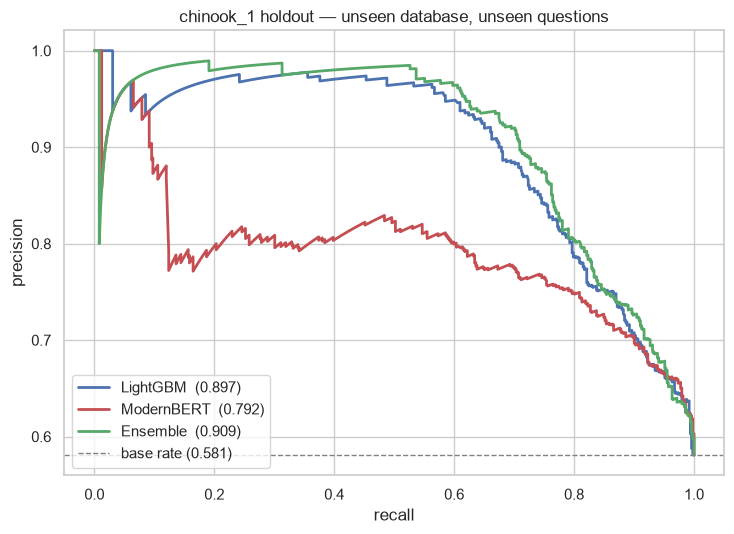

In [13]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for name, p, c in [("LightGBM", p_lgbm, "#4C72B0"),
                   ("ModernBERT", p_bert, "#C44E52"),
                   ("Ensemble", hold.p_fail.values, "#55A868")]:
    if p is None:
        continue
    pr, rc, _ = precision_recall_curve(y, p)
    ax.plot(rc, pr, color=c, lw=2,
            label=f"{name}  ({average_precision_score(y, p):.3f})")
ax.axhline(base_hold, color="grey", ls="--", lw=1, label=f"base rate ({base_hold:.3f})")
ax.set_xlabel("recall"); ax.set_ylabel("precision")
ax.set_title("chinook_1 holdout — unseen database, unseen questions")
ax.legend(loc="lower left"); plt.tight_layout(); plt.show()

## 4. What actually matters: does early stopping still work?

PR-AUC is a ranking measure. The deployed question is narrower and more
concrete: **on an unseen database, how much compute does the critic save, and
how many correct answers does it destroy?**

On the test set at threshold 0.90 that was 34% of steps saved for 2 of 83
answers lost. Same simulation, same thresholds, new database.

In [14]:
from scripts.measure_early_stop import simulate, sweep

print("=" * 74)
print("  threshold sweep on the HOLDOUT — unseen database")
print("=" * 74)
print(sweep(hold).round(2).to_string(index=False))
print("=" * 74)

  threshold sweep on the HOLDOUT — unseen database
 threshold  steps saved %  answers lost %  failures caught %  answers lost
      0.30          59.27           78.40             100.00           127
      0.40          54.66           67.28              95.65           109
      0.50          44.04           39.51              86.96            64
      0.60          37.43           22.22              82.61            36
      0.69          29.28            6.79              76.09            11
      0.75          24.91            3.70              68.12             6
      0.80          20.90            0.62              63.04             1
      0.85          17.83            0.62              56.52             1
      0.90          12.99            0.62              44.93             1
      0.95           7.44            0.62              32.61             1


In [15]:
# Side by side with the test set. The comparison, not the absolute number,
# is the result.
TEST_SWEEP = {          # measured in the previous notebook / script run
    0.90: {"saved": 33.98, "lost": 2.41},
    0.95: {"saved": 23.98, "lost": 1.20},
    0.694: {"saved": 53.01, "lost": 13.25},
}

print(f"{'threshold':<11}{'steps saved %':>26}{'answers lost %':>26}")
print(f"{'':11}{'test':>13}{'holdout':>13}{'test':>13}{'holdout':>13}")
print("-" * 63)
for t, ref in sorted(TEST_SWEEP.items()):
    sim = simulate(hold, t)
    n_ok = int((~sim.failed).sum())
    total = int(sim.n_steps.sum())
    saved = 100 * (total - sim.steps_run.sum()) / total
    lost = 100 * sim.answer_lost.sum() / max(n_ok, 1)
    print(f"{t:<11}{ref['saved']:>13.1f}{saved:>13.1f}"
          f"{ref['lost']:>13.1f}{lost:>13.1f}")

threshold               steps saved %            answers lost %
                    test      holdout         test      holdout
---------------------------------------------------------------
0.694               53.0         29.3         13.2          6.8
0.9                 34.0         13.0          2.4          0.6
0.95                24.0          7.4          1.2          0.6


In [16]:
# The recommended operating point, in full.
from scripts.measure_early_stop import report

sim = simulate(hold, 0.90)
summary = report(sim, 0.90, f"{critic.version} — chinook_1 holdout")


  early stopping at threshold 0.9   [lgbm0.7+bert0.3 — chinook_1 holdout]
  300 runs   138 failed   162 succeeded

  steps without critic       847
  steps with critic          737
  STEPS SAVED                110   (13.0%)

  failing runs caught         62 / 138  (44.9%)
  ANSWERS LOST                 1 / 162  (0.6%)

  solve rate before      54.0%
  solve rate after       53.7%

  median stop step on caught failures: 2


## 5. Where does it go wrong here?

If performance dropped, the useful question is *which* steps it now misjudges.
Chinook has different table names, shorter queries and different question
phrasing — any of those could be the cause, and knowing which one points at
the fix.

In [17]:
thr = 0.90
pred = (hold.p_fail.values > thr).astype(int)

print(f"at threshold {thr}:")
print(f"  correctly stopped   {((pred == 1) & (y == 1)).sum():>4}")
print(f"  wrongly stopped     {((pred == 1) & (y == 0)).sum():>4}   <- lost answers")
print(f"  missed failures     {((pred == 0) & (y == 1)).sum():>4}")
print(f"  correctly continued {((pred == 0) & (y == 0)).sum():>4}")

wrong = hold[(pred == 1) & (y == 0)]
if len(wrong):
    print(f"\n{len(wrong)} steps from GOOD runs that the critic wanted to stop:\n")
    for _, r in wrong.head(4).iterrows():
        print("-" * 74)
        print(f"  question : {r.question[:90]}")
        print(f"  sql      : {str(r.sql)[:150] if r.sql else '(none)'}")
        print(f"  step     : {r.step_index}   p_fail = {r.p_fail:.3f}")
else:
    print("\nno good runs were stopped at this threshold")

at threshold 0.9:
  correctly stopped    146
  wrongly stopped        2   <- lost answers
  missed failures      346
  correctly continued  353

2 steps from GOOD runs that the critic wanted to stop:

--------------------------------------------------------------------------
  question : How many customers have email that contains "gmail.com"?
  sql      : (none)
  step     : 2   p_fail = 0.942
--------------------------------------------------------------------------
  question : How many customers have email that contains "gmail.com"?
  sql      : (none)
  step     : 3   p_fail = 0.988


In [18]:
# Query length is the most likely culprit if it dropped: chinook questions are
# simpler than formula_1's, so the critic may read "short query" as "hasn't
# done the work yet".
comp = pd.DataFrame({
    "training": [train.sql.fillna("").str.len().mean(),
                 train.groupby("run_id").size().mean(),
                 train.question.str.split().str.len().mean()],
    "holdout": [hold.sql.fillna("").str.len().mean(),
                hold.groupby("run_id").size().mean(),
                hold.question.str.split().str.len().mean()],
}, index=["mean sql length (chars)", "mean steps per run", "mean question words"])
print(comp.round(1).to_string())

                         training  holdout
mean sql length (chars)      95.4     71.8
mean steps per run            3.4      2.8
mean question words          14.7     11.9


## 6. Conclusion

**The critic transfers.** Measured on 847 steps from 300 runs over 30 questions
against `chinook_1` — a database, schema and question set it had never seen.

| critic | captured (test) | captured (holdout) | retained |
|---|---|---|---|
| LightGBM | 0.901 | 0.755 | **84%** |
| ModernBERT | 0.859 | 0.503 | **59%** |
| **Ensemble** | **0.916** | **0.782** | **86%** |

Roughly **85% of performance survives** the move to an unseen database. The
numbers in notebooks 02 and 05 were not an artifact of memorised questions.

---

### ModernBERT is the weak component

**59% retained against LightGBM's 84%.** The precision-recall curve shows it
plainly: the text critic collapses to ~0.80 precision almost immediately and
stays flat, while LightGBM and the ensemble hold ~0.97 across most of the
range.

This confirms what notebook 04 section 6 warned about. The strongest n-grams
were question words and table names — `advisors`, `2017`, `student?` — and on a
schema with none of those, much of the advantage disappears.

It still helps slightly: the ensemble beats LightGBM alone here, 0.9088 to
0.8972. So the decision in notebook 05 to keep both survives, but on a much
thinner margin than the test set suggested. State it that way rather than
citing the 0.9845.

### Early stopping saves less here — and that is the right outcome

At threshold 0.90:

| | test set | holdout |
|---|---|---|
| steps saved | 34.0% | **13.0%** |
| answers lost | 2.4% | **0.6%** (1 of 162) |
| failures caught | 79.0% | 44.9% |

Less compute saved, because there is less waste to remove. Chinook runs are
shorter (2.8 steps against 3.4) and **54% of them succeed against 27.5%** on
the training databases. A critic cannot save work that was never being wasted.

Meanwhile answer loss fell from 2.4% to 0.6% — a single run out of 162.

**On this data, 0.80 is the better operating point:**

```
0.80    20.9% saved    1 answer lost    63.0% failures caught
0.90    13.0% saved    1 answer lost    44.9% failures caught
```

Same single lost answer, 60% more compute saved. The threshold should be tuned
per deployment rather than carried across from another database — which is
itself a finding worth reporting.

### What this means for the write-up

> A step-level critic trained on two databases retains 86% of its achievable
> discrimination on a third it has never seen, cutting 13-21% of agent steps
> while losing 1 correct answer in 162. The feature-based component transfers
> substantially better than the text-based one (84% against 59%), indicating
> the text model partly keys on schema-specific vocabulary.

That last clause is the most interesting sentence in the project. It is a
measured, mechanistic claim about *why* one approach generalises and the other
does not — which is worth considerably more than a larger number with no
explanation.

### Limits, stated plainly

1. **One holdout database.** `chinook_1` is a music store; the training
   databases were a university and a motorsport league. A single transfer test
   is evidence, not proof. Three databases would make it a trend.
2. **300 runs, 30 questions.** The 0.6% answer loss is a single run. Do not
   quote it to two decimal places.
3. **Chinook is easier** — 54% solve rate against 27.5%. Some of the improved
   answer preservation is the database being simpler, not the critic being
   better on it.
4. **The labels are still run-level.** Every step in a failed run is marked
   bad, including the good ones. That ceiling applies here exactly as it did
   before, and the LLM annotator remains the fix.